# Notebook for model training

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, 
                             precision_score, recall_score, f1_score, 
                             )
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("data/clean_data.csv")
print(df.head())
print(df.columns)

   Unnamed: 0  age gender  daily_screen_time_hours  social_media_hours  \
0           0   21   Male                     3.23                2.01   
1           1   24  Other                     5.09                3.81   
2           2   31  Other                     6.06                1.36   
3           3   32  Other                     7.83                5.85   
4           4   25   Male                     9.96                5.92   

   gaming_hours  work_study_hours  sleep_hours  notifications_per_day  \
0          0.89              4.55         7.55                    248   
1          2.24              4.44         7.66                    127   
2          3.83              2.35         4.92                     44   
3          1.51              3.54         8.23                    178   
4          3.42              5.27         6.21                    136   

   app_opens_per_day  weekend_screen_time stress_level academic_work_impact  \
0                154                 

In [46]:

y = df["addicted_label"].copy()
X = df.copy()
X = X.drop(columns=['addiction_level', 'addicted_label'])

ord_features = ['academic_work_impact']
oh_features = ['gender', 'stress_level']

col_transformer = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(), ord_features),
        ('oh', OneHotEncoder(), oh_features)
    ], remainder='passthrough'
    )

X = col_transformer.fit_transform(X)
feature_names = col_transformer.get_feature_names_out()
feature_names = [i.split('__')[-1] for i in feature_names]
X = pd.DataFrame( X, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)


In [47]:
print(y.value_counts())
print(X.head())

addicted_label
1    5308
0    2192
Name: count, dtype: int64
   academic_work_impact  gender_Female  gender_Male  gender_Other  \
0                   1.0            0.0          1.0           0.0   
1                   1.0            0.0          0.0           1.0   
2                   0.0            0.0          0.0           1.0   
3                   1.0            0.0          0.0           1.0   
4                   0.0            0.0          1.0           0.0   

   stress_level_High  stress_level_Low  stress_level_Medium  Unnamed: 0   age  \
0                0.0               0.0                  1.0         0.0  21.0   
1                0.0               0.0                  1.0         1.0  24.0   
2                1.0               0.0                  0.0         2.0  31.0   
3                1.0               0.0                  0.0         3.0  32.0   
4                0.0               1.0                  0.0         4.0  25.0   

   daily_screen_time_hours  social_me

In [48]:
rf = RandomForestClassifier(n_estimators=200)

scores = cross_val_score(rf, X_train, y_train, cv=5)

rf.fit(X_train, y_train)

print(f"Scores per fold: {scores}")
print(f"Average Accuracy: {scores.mean():.2f}")

Scores per fold: [0.95416667 0.9175     0.9375     0.92916667 0.93333333]
Average Accuracy: 0.93


In [52]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importances.sort_values)

<bound method Series.sort_values of social_media_hours         0.348623
daily_screen_time_hours    0.315705
weekend_screen_time        0.181047
sleep_hours                0.021310
work_study_hours           0.020731
gaming_hours               0.020489
Unnamed: 0                 0.020187
app_opens_per_day          0.019642
notifications_per_day      0.019418
age                        0.014278
academic_work_impact       0.002975
gender_Male                0.002883
gender_Other               0.002828
stress_level_Low           0.002586
stress_level_Medium        0.002528
stress_level_High          0.002515
gender_Female              0.002257
dtype: float64>


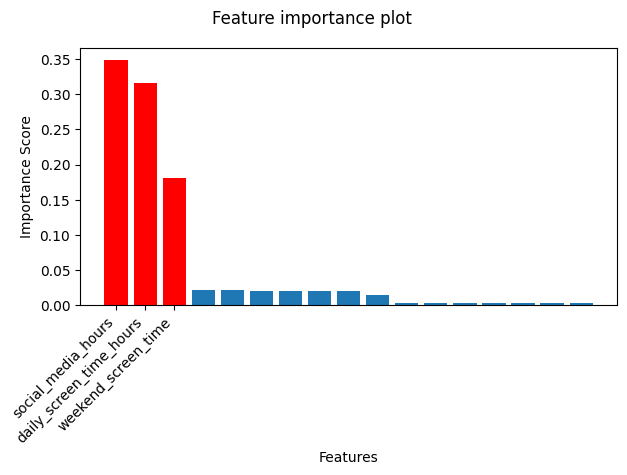

In [60]:
chosen_features = ['social_media_hours', 'daily_screen_time_hours', 'weekend_screen_time']
plt.bar(range(len(importances)), importances)
plt.bar(range(3), importances[:3], color='red')
plt.xticks(ticks=[0, 1, 2], labels=chosen_features, rotation=45, ha='right')
plt.suptitle("Feature importance plot")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.tight_layout()

In [ ]:
X_train = X_train[chosen_features]
X_test = X_test[chosen_features]

Index(['social_media_hours', 'daily_screen_time_hours', 'weekend_screen_time'], dtype='object')


In [68]:
final_tree = RandomForestClassifier(n_estimators = 100)
final_tree.fit(X_train, y_train)
y_pred = final_tree.predict(X_test)

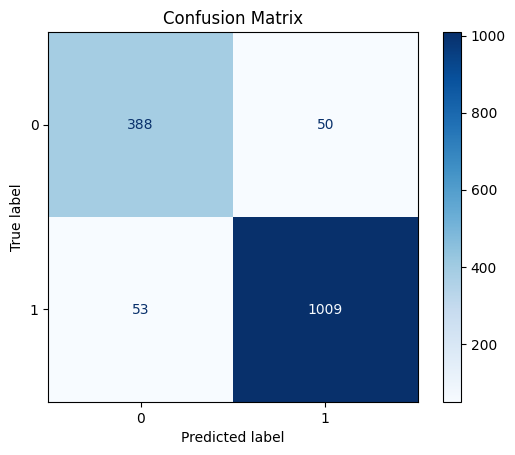

In [70]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
